In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saurabhbadole/zomato-delivery-operations-analytics-dataset/Zomato Dataset.csv


In [6]:
import seaborn as sb
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("/kaggle/input/datasets/saurabhbadole/zomato-delivery-operations-analytics-dataset/Zomato Dataset.csv")

# 1. Basic structure

In [8]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [9]:
df.shape

(45584, 20)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

# 2. Data quality issues

In [11]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64

In [12]:
df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)
df['Delivery_person_Age'].isnull().sum()

/tmp/ipykernel_58/1757839826.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)


np.int64(0)

In [13]:
df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median(), inplace=True)
df['Delivery_person_Ratings'].isnull().sum()

/tmp/ipykernel_58/4130294812.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median(), inplace=True)


np.int64(0)

In [14]:
for col in ['Weather_conditions', 'Road_traffic_density', 'Festival', 'City']:
    df[col].fillna(df[col].mode()[0], inplace=True)
df['Weather_conditions'].isnull().sum()

/tmp/ipykernel_58/3201203968.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


np.int64(0)

In [15]:
df[df['multiple_deliveries'].isnull()]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
8,0x6f67,HYDRES14DEL01,34.0,4.9,17.426228,78.407495,17.496228,78.477495,20-03-2022,20:40,20:50,Cloudy,Jam,0,Snack,motorcycle,NaN,No,Metropolitian,41
77,0x837c,PUNERES14DEL02,39.0,4.8,18.516216,73.842527,18.566216,73.892527,03-03-2022,21:55,22:10,Stormy,Jam,1,Meal,motorcycle,NaN,No,Metropolitian,28
86,0xb437,SURRES16DEL01,25.0,5.0,21.160437,72.774209,21.270437,72.884209,18-03-2022,20:25,20:40,Stormy,Jam,1,Meal,motorcycle,NaN,No,Metropolitian,15
126,0x894e,BANGRES12DEL02,28.0,4.8,12.939496,77.625999,12.989496,77.675999,24-03-2022,23:10,23:15,Fog,Low,1,Drinks,motorcycle,NaN,No,Metropolitian,18
135,0x4008,SURRES010DEL02,29.0,4.6,21.171060,72.789292,21.251060,72.869292,12-03-2022,19:40,19:55,Sunny,Jam,2,Meal,electric_scooter,NaN,No,Metropolitian,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45038,0xac9,RANCHIRES12DEL02,36.0,4.8,0.000000,0.000000,0.020000,0.020000,11-03-2022,08:15,08:30,Sunny,Low,1,Snack,scooter,NaN,No,Urban,15
45066,0xb8a5,VADRES08DEL03,23.0,4.7,0.000000,0.000000,0.090000,0.090000,31-03-2022,23:20,23:35,Sandstorms,Low,2,Snack,scooter,NaN,No,Urban,17
45071,0x7324,CHENRES11DEL03,29.0,4.6,13.064181,80.236442,13.094181,80.266442,03-03-2022,17:40,17:55,Fog,Medium,1,Drinks,scooter,NaN,No,Urban,15
45142,0x954a,INDORES02DEL02,22.0,4.8,22.651847,75.881991,22.701847,75.931991,28-03-2022,20:45,0.875,Stormy,Jam,1,Snack,scooter,NaN,No,Urban,14


In [16]:
df['multiple_deliveries'].fillna(0, inplace=True)
df[df['multiple_deliveries'].isnull()]

/tmp/ipykernel_58/2486757556.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['multiple_deliveries'].fillna(0, inplace=True)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)


In [17]:
df1 = df.copy()
df2 = df.copy()

# Convert both to datetime first (combine with a dummy date if needed)
df2['Time_Orderd_dt'] = pd.to_datetime(df2['Time_Orderd'], format='%H:%M', errors='coerce')
df2['Time_Order_picked_dt'] = pd.to_datetime(df2['Time_Order_picked'], format='%H:%M', errors='coerce')

# Average prep gap where both exist
valid_gap = (df2['Time_Order_picked_dt'] - df2['Time_Orderd_dt']).dropna()
avg_gap = valid_gap.mean()

# Fill missing Time_Orderd using picked time minus average gap
mask = df2['Time_Orderd_dt'].isna()
df2.loc[mask, 'Time_Orderd_dt'] = df2.loc[mask, 'Time_Order_picked_dt'] - avg_gap

In [18]:
df2.isnull().sum()  #NOT WORKING ON THIS RIGHT NOW

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken (min)                  0
Time_Orderd_dt                  629
Time_Order_picked_dt           5007
dtype: int64

In [19]:
df1.isnull().sum()  #working on df1 right now

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken (min)                  0
dtype: int64

In [20]:
df1 = df1.dropna(subset=['Time_Orderd'])
df1.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
dtype: int64

In [21]:
df1.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
dtype: object

# 3. Target variable analysis

In [22]:
df1['Time_taken (min)'].describe()  #This gives you min, max, mean, median, std, quartiles — first sanity check for anything absurd (e.g. 1 minute or 200+ minute deliveries).

count    43853.000000
mean        26.293161
std          9.374274
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64

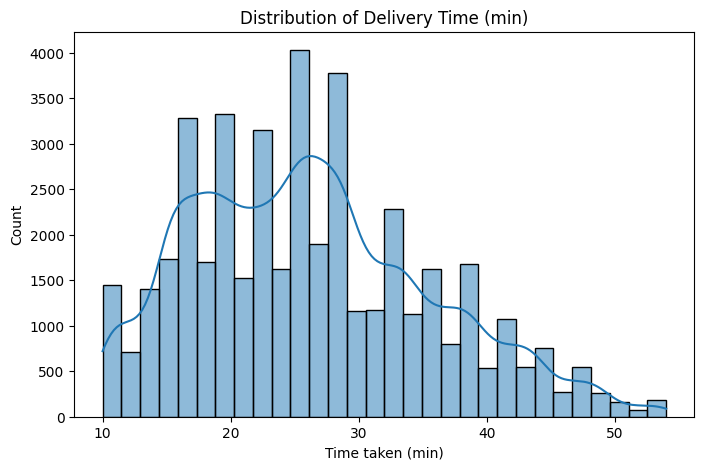

In [23]:
#Distribution shape — histogram + KDE

plt.figure(figsize=(8,5))
sb.histplot(df1['Time_taken (min)'],kde=True,bins=30)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Time taken (min)')
plt.show()

#Look for: is it roughly normal, or right-skewed (long tail toward high delivery times)? Delivery time data is often right-skewed, which matters later — you may want to log-transform the target for linear models.

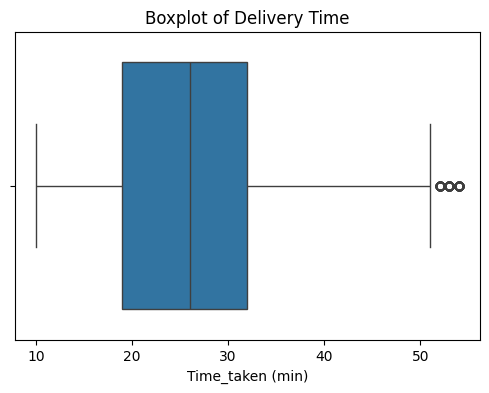

In [24]:
#Boxplot for outliers

plt.figure(figsize=(6,4))
sb.boxplot(x=df1['Time_taken (min)'])
plt.title('Boxplot of Delivery Time')
plt.show()

#This shows you the IQR and any points beyond the whiskers — potential outliers to investigate.

In [25]:
#Skewness and kurtosis (numeric confirmation of shape)

print('Skewness:', df1['Time_taken (min)'].skew())
print('Kurtosis:', df1['Time_taken (min)'].kurt())

#Skewness close to 0 → symmetric. Positive → right-skewed (long tail on high end).
#High kurtosis → heavy tails / more outliers than a normal distribution.

Skewness: 0.48347331924264164
Kurtosis: -0.3140957040347585


In [26]:
# Check for any nonsensical values

print(df1['Time_taken (min)'].min())
print(df1['Time_taken (min)'].max())
print((df1['Time_taken (min)'] <= 0).sum())  # any zero or negative times?

#Delivery time should never be 0 or negative — if you find any, those rows likely need to be dropped or investigated.

10
54
0


Step 3 is done, and the results are reassuring. Here's what the numbers say:

No transformation needed. Skewness of 0.48 is mild right skew — the common rule of thumb is that |skew| < 0.5 counts as approximately symmetric. Kurtosis of −0.31 is slightly negative, meaning lighter tails than a normal distribution, i.e. fewer extreme values than you'd expect by chance. So you can skip the **log1p** transform I mentioned earlier. Model the raw target directly.

The outliers aren't really outliers. The boxplot flags a few points around 52–54 min, but the max is 54 and the min is 10 — both entirely plausible delivery times. These aren't data-entry errors, they're just genuinely slow deliveries (probably festival + jam traffic + long distance). Keep them. Dropping them would throw away exactly the hard cases your model needs to learn.

Data is clean. Zero non-positive values, so nothing to remove.
The most interesting finding is the shape. Look at the histogram — that's not a single smooth hump. There's a distinct peak around 18 minutes and a bigger one around 26, with the KDE dipping between them. That bimodality is a signal, not noise. It almost certainly means your target is being pulled by one or more categorical features that split the data into distinct regimes — most likely **Road_traffic_density** (Low vs Jam) or **City** (Urban vs Metropolitian), possibly **Festival**.

This is genuinely good news for your project. It means the categorical features carry real predictive signal, and a tree-based model (Random Forest, XGBoost, LightGBM) will capture these regimes well — better than linear regression, which struggles with multi-modal structure.

<Axes: xlabel='Time_taken (min)', ylabel='Count'>

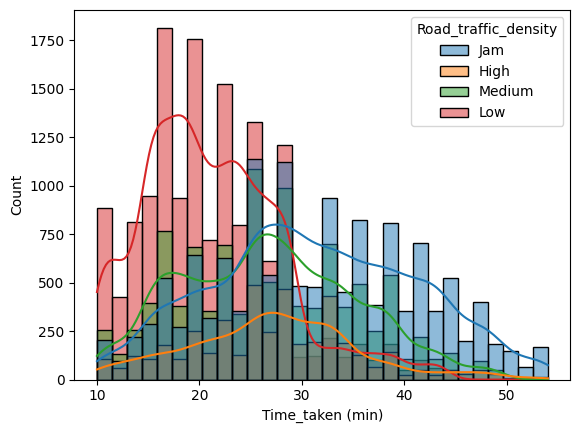

In [27]:
sb.histplot(data=df1, x='Time_taken (min)', hue='Road_traffic_density', kde=True, bins=30)

Road_traffic_density explains the bimodal shape you saw earlier:

Low traffic (red) peaks sharply around 15–20 min and drops off fast after 30 — these are your quick deliveries.
Jam (blue) is shifted way right, peaking around 25–30 min and tailing all the way out to 50+ — these are your slow deliveries.
Medium (green) and High (orange) sit in between, roughly where you'd expect.

So the "two humps" in the overall histogram were really the Low-traffic cluster and the Jam-traffic cluster showing through. This is a strong signal — Road_traffic_density is going to be one of your most important predictive features, and it also tells you a tree-based model will outperform plain linear regression here, since it can naturally split on traffic category rather than forcing one smooth curve through clearly separate regimes.

# 4: univariate analysis of the features.

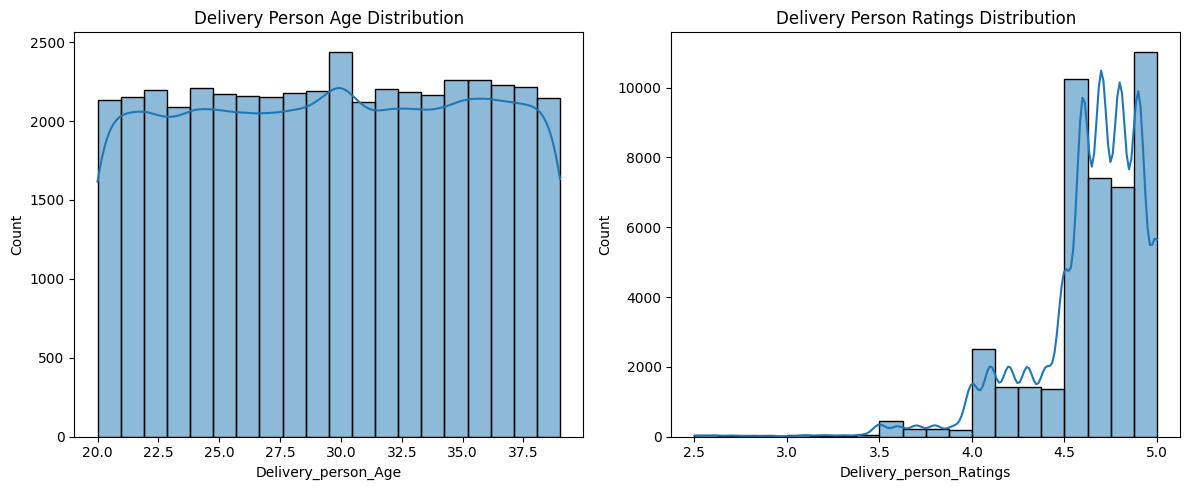

In [28]:
# 1. Numeric features — distribution:

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sb.histplot(df1['Delivery_person_Age'], kde=True, bins=20, ax=axes[0])
axes[0].set_title('Delivery Person Age Distribution')

sb.histplot(df1['Delivery_person_Ratings'], kde=True, bins=20, ax=axes[1])
axes[1].set_title('Delivery Person Ratings Distribution')
plt.tight_layout()
plt.show()

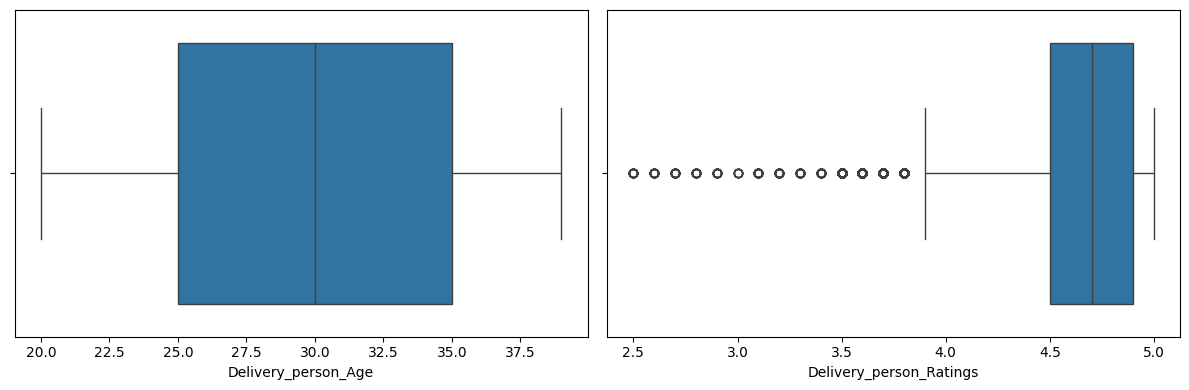

In [29]:
#2. Numeric features — boxplots for outliers:

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sb.boxplot(x=df1['Delivery_person_Age'], ax=axes[0])
sb.boxplot(x=df1['Delivery_person_Ratings'], ax=axes[1])
plt.tight_layout()
plt.show()

Numeric features

Age is almost perfectly uniform from 20 to 39 — flat bars, no peak, no outliers in the boxplot. That's a tell: real-world age distributions are never this flat. This column was likely synthetically generated (random uniform draw), which means it probably carries little to no predictive power. Don't drop it yet, but don't be surprised when it ranks near the bottom on feature importance.

Ratings is the opposite — heavily left-skewed, tightly clustered between 4.5 and 5.0, with a long thin tail of low values (2.5–4.0) that the boxplot flags as outliers. Those low-rated deliverers are real and probably meaningful (a 2.5-rated driver plausibly delivers slower). Keep them — same logic as before, they're the informative hard cases, not errors. The 4.0 bump around 2500 rows is also worth noting; possibly a default value for new drivers.

In [30]:
#3. Categorical features — value counts (text, quick check):

cat_cols = ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 
            'Type_of_vehicle', 'Festival', 'City', 'multiple_deliveries', 'Vehicle_condition']

for col in cat_cols:
    print(f"\n{col}:")
    print(df1[col].value_counts())


Weather_conditions:
Weather_conditions
Fog           7475
Stormy        7400
Cloudy        7336
Sandstorms    7284
Windy         7251
Sunny         7107
Name: count, dtype: int64

Road_traffic_density:
Road_traffic_density
Low       15061
Jam       13796
Medium    10676
High       4320
Name: count, dtype: int64

Type_of_order:
Type_of_order
Snack     11088
Meal      11016
Drinks    10896
Buffet    10853
Name: count, dtype: int64

Type_of_vehicle:
Type_of_vehicle
motorcycle          25627
scooter             14692
electric_scooter     3534
Name: count, dtype: int64

Festival:
Festival
No     42996
Yes      857
Name: count, dtype: int64

City:
City
Metropolitian    33940
Urban             9757
Semi-Urban         156
Name: count, dtype: int64

multiple_deliveries:
multiple_deliveries
1.0    27060
0.0    14530
2.0     1920
3.0      343
Name: count, dtype: int64

Vehicle_condition:
Vehicle_condition
2    14639
1    14615
0    14599
Name: count, dtype: int64


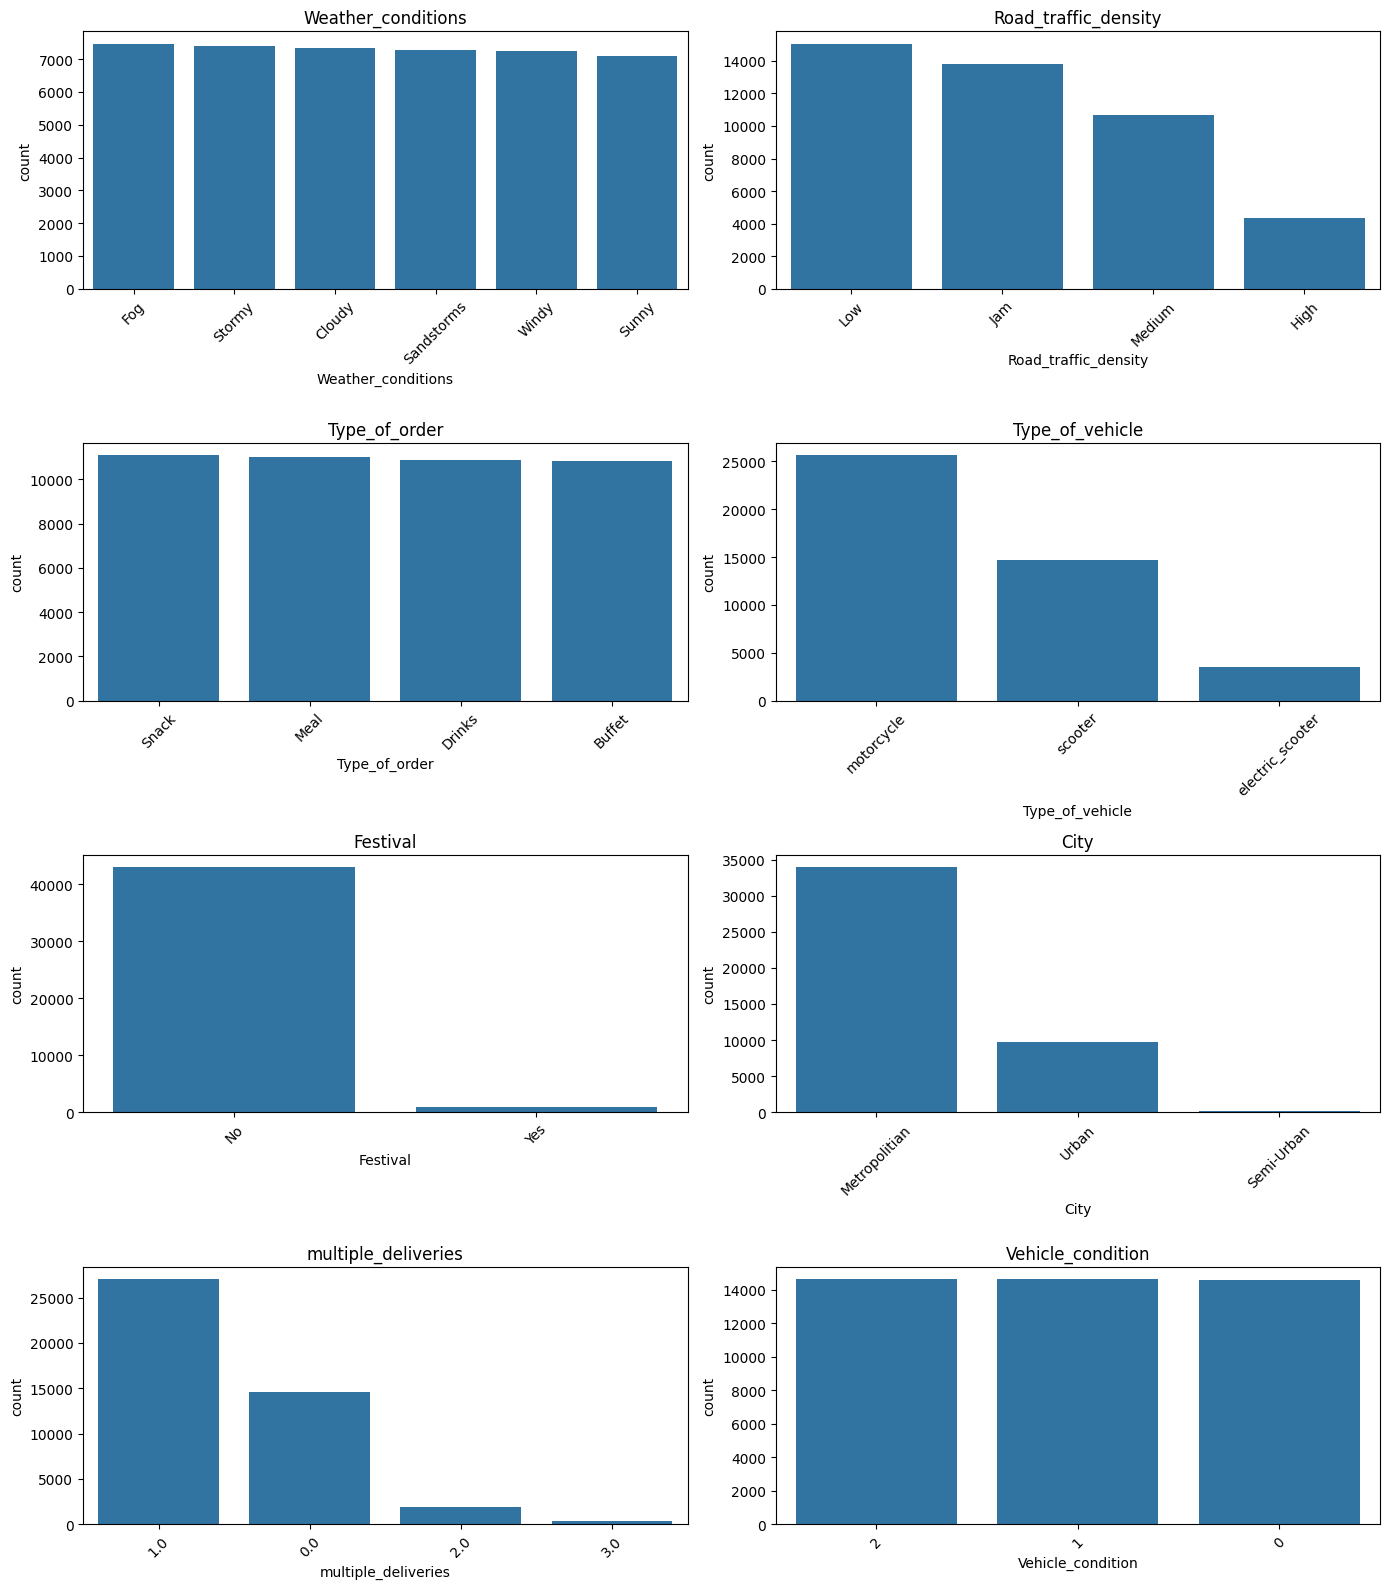

In [31]:
# 4. Categorical features — bar plots (visual, easier to spot imbalance):

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sb.countplot(data=df1, x=col, ax=axes[i], order=df1[col].value_counts().index)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Categorical features — the important patterns

These four are suspiciously balanced: Weather_conditions (all ~7100–7475), Type_of_order (all ~10850–11088), and Vehicle_condition (all ~14600). Near-perfect uniformity again suggests synthetic generation. Type_of_order in particular is dead flat across all four categories — expect it to be a weak predictor. Weather_conditions might still matter despite being balanced, since balance in the feature doesn't preclude a real effect on the target. Step 5 will tell us.

These carry real structure:

Road_traffic_density — you've already confirmed this is your strongest signal.
Type_of_vehicle — realistically skewed (motorcycle dominant, electric_scooter rare).
multiple_deliveries — sensible distribution, and logically should increase delivery time.

City has a severe imbalance problem. Semi-Urban has only 156 rows out of 43,853 — that's 0.36%. This is small enough to cause trouble: after a train/test split, you might get a handful of Semi-Urban rows in test, and your model will have learned almost nothing about that category. Same concern, milder, for Festival (857 "Yes", ~2%).

Options for City:

Leave it as-is — tree models handle rare categories okay, and 156 rows will just get absorbed into a leaf. Simplest.
Merge Semi-Urban into Urban — defensible, they're conceptually adjacent.
Use stratified splitting later so the rare category is proportionally represented in train and test.

Recommended: leave the category but use stratification when you split, and just be aware that any model prediction for Semi-Urban carries high uncertainty. Don't merge — you'd be destroying a real distinction to solve a problem that trees mostly handle on their own.

For Festival, definitely keep it. Rare events with strong effects are exactly what you want a model to capture, and festival deliveries are very likely much slower.

In [32]:
df1['multiple_deliveries'] = df1['multiple_deliveries'].astype(int)
# Cast multiple_deliveries to int, since it's a count sitting as float:

In [33]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')

In [34]:
df.groupby("City")["Time_taken (min)"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
City,,,,
Metropolitian,35287,27.135716,26.0,9.205654
Semi-Urban,164,49.731707,49.0,2.693089
Urban,10133,22.983322,22.0,8.867217


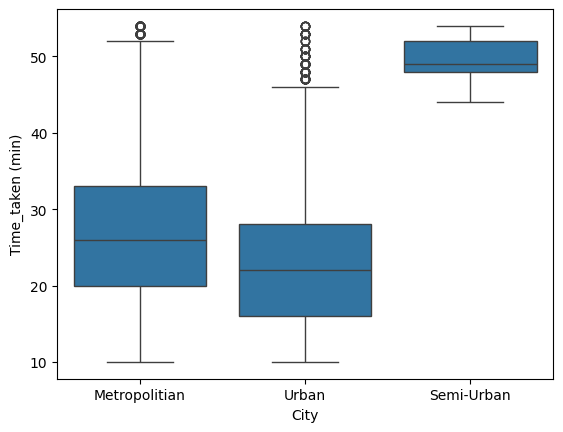

In [35]:
sb.boxplot(
    x="City",
    y="Time_taken (min)",
    data=df
)

plt.show()

The about two cells clearly show that semi-urban is high importance feature as they affect our output variable heavily.

# 5: Bivariate analysis — every feature vs. the target.

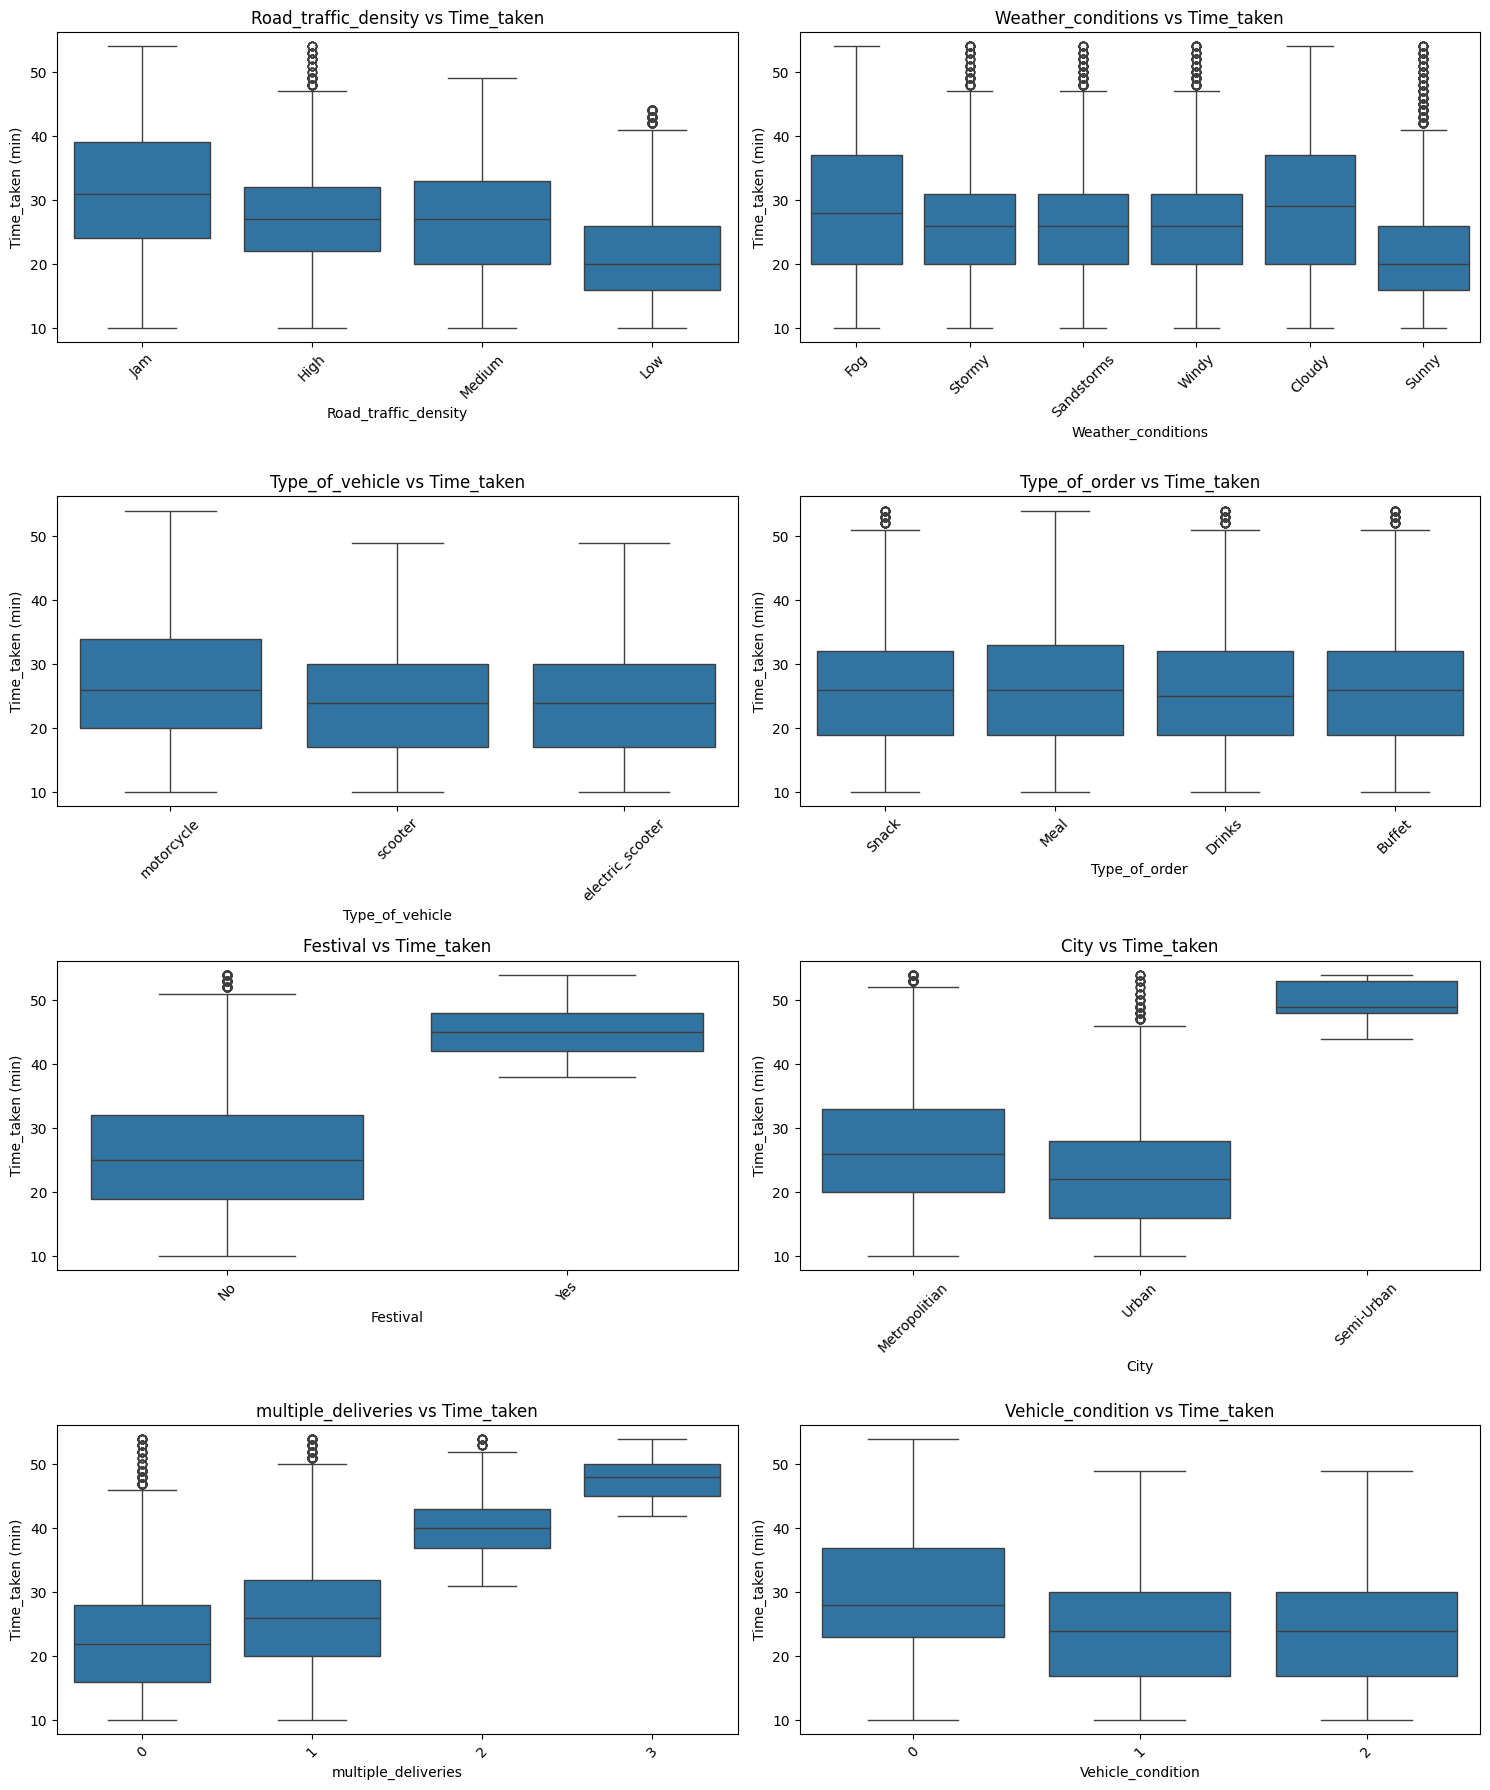

In [36]:
#1. Categorical features vs target (boxplots):

cat_cols = ['Road_traffic_density', 'Weather_conditions', 'Type_of_vehicle', 
            'Type_of_order', 'Festival', 'City', 'multiple_deliveries', 'Vehicle_condition']

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sb.boxplot(data=df1, x=col, y='Time_taken (min)', ax=axes[i])
    axes[i].set_title(f'{col} vs Time_taken')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [37]:
# 2. The same thing numerically — mean delivery time per category:

for col in cat_cols:
    print(f"\n{col}:")
    print(df1.groupby(col)['Time_taken (min)'].agg(['mean', 'median', 'count']).round(2))


Road_traffic_density:
                       mean  median  count
Road_traffic_density                      
High                  27.21    27.0   4320
Jam                   31.15    31.0  13796
Low                   21.28    20.0  15061
Medium                26.72    27.0  10676

Weather_conditions:
                     mean  median  count
Weather_conditions                      
Cloudy              28.94    29.0   7336
Fog                 28.93    28.0   7475
Sandstorms          25.89    26.0   7284
Stormy              25.86    26.0   7400
Sunny               21.85    20.0   7107
Windy               26.10    26.0   7251

Type_of_vehicle:
                   mean  median  count
Type_of_vehicle                       
electric_scooter  24.41    24.0   3534
motorcycle        27.60    26.0  25627
scooter           24.47    24.0  14692

Type_of_order:
                mean  median  count
Type_of_order                      
Buffet         26.29    26.0  10853
Drinks         26.20    25.0  108

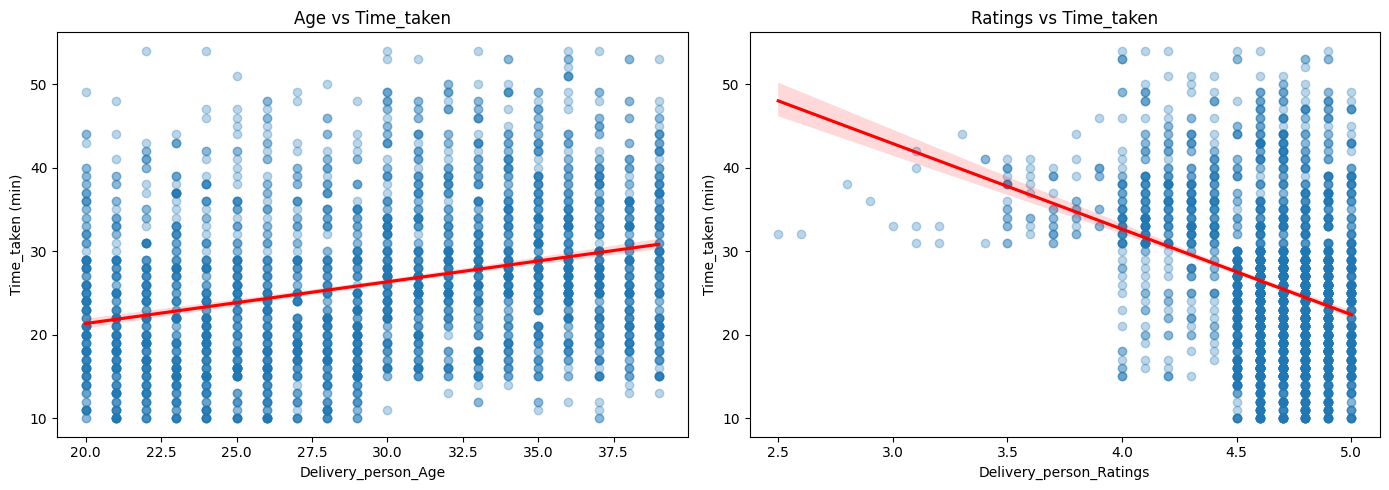

In [38]:
# 3. Numeric features vs target (scatter + trend):
# With ~44k points a raw scatter will be a solid blob, so bin the ratings and use a regression line for age:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs target - sample to keep it readable
sb.regplot(data=df1.sample(3000, random_state=42), x='Delivery_person_Age', 
            y='Time_taken (min)', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Age vs Time_taken')

sb.regplot(data=df1.sample(3000, random_state=42), x='Delivery_person_Ratings', 
            y='Time_taken (min)', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Ratings vs Time_taken')

plt.tight_layout()
plt.show()

In [39]:
# 4. Ratings binned — clearer than a scatter:

df1['rating_bin'] = pd.cut(df1['Delivery_person_Ratings'], bins=[2.5, 3.5, 4.0, 4.5, 4.8, 5.0])
print(df1.groupby('rating_bin')['Time_taken (min)'].agg(['mean', 'count']).round(2))
df1.drop('rating_bin', axis=1, inplace=True)  # temp column, remove after

             mean  count
rating_bin              
(2.5, 3.5]  36.83    452
(3.5, 4.0]  35.88   1934
(4.0, 4.5]  30.56   8919
(4.5, 4.8]  24.28  21492
(4.8, 5.0]  24.63  11036


/tmp/ipykernel_58/3219675488.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df1.groupby('rating_bin')['Time_taken (min)'].agg(['mean', 'count']).round(2))


Earlier it was that predicted a flat line because the distribution was uniform. The regplot shows a clear upward slope — roughly 21 min at age 20 rising to ~31 min at age 39. That's a 10-minute swing, which is substantial. The lesson: a uniform feature distribution says nothing about whether the feature relates to the target. Keep Delivery_person_Age. It earns its place.

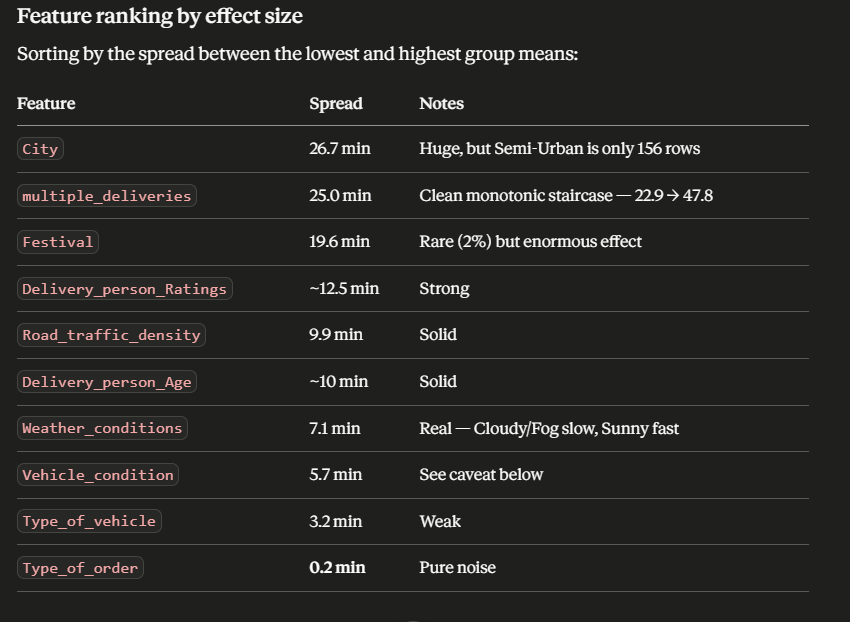

**Three things you must act on**

1. **Type_of_order** is dead. Means of 26.20, 26.27, 26.29, 26.42. That's a 0.2-minute spread across 44k rows — statistically indistinguishable from zero. Drop it. It adds four one-hot columns of pure noise.

In [40]:
df1.drop('Type_of_order', axis=1, inplace=True)

2. **Vehicle_condition** is NOT ordinal. Look closely: condition 0 → 30.05 min, condition 1 → 24.37, condition 2 → 24.47. It goes down then flat, not down-down or up-up. Right now it's stored as **int64**, so a linear model will fit a straight line through a non-monotonic relationship and get it wrong. **One-hot encode it as a categorical, not as a number.**

3. **Delivery_person_Ratings** is non-linear. The binned table is the tell:

(2.5, 3.5] → 36.83

(3.5, 4.0] → 35.88

(4.0, 4.5] → 30.56

(4.5, 4.8] → 24.28

(4.8, 5.0] → 24.63 ← goes back up slightly

There's a steep decline until 4.5, then a plateau. That red regression line in your scatter plot is a lie — it's forcing a straight line through a curve. Above 4.5 (which is 74% of your data), ratings barely matter at all.

**What this means for modeling**

You now have three separate pieces of evidence — bimodal target, non-monotonic **Vehicle_condition**, plateaued **Ratings** — all pointing the same direction: linear regression will underperform here, and tree-based models (Random Forest, XGBoost, LightGBM) will do well. Still fit Linear Regression as your baseline; it's the honest comparison point. But expect the trees to beat it decisively, and now you'll know exactly why.

One more note on **City**: Semi-Urban averages 49.74 min versus 23.00 for Urban. That's the single largest effect in the dataset — and it rests on 156 rows. Definitely stratify your train/test split on this column so the category appears in both.

# 6: Geospatial feature engineering — haversine distance.

In [41]:
# 1. Inspect the coordinate ranges:

df1[['Restaurant_latitude', 'Restaurant_longitude', 
     'Delivery_location_latitude', 'Delivery_location_longitude']].describe()

# India's valid range is roughly latitude 8–37, longitude 68–97. Watch for two known problems:

#1. Zeros or near-zeros (e.g. 0.0, 0.01) — missing data encoded as 0
#2. Negative latitudes — this dataset has rows where the sign is flipped (e.g. -22.7 instead of 22.7)

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,43853.000000,43853.000000,43853.000000,43853.000000
mean,17.242245,70.763328,17.462771,70.826921
std,7.699200,21.138033,7.338998,21.138202
min,-30.902872,0.000000,0.010000,0.010000
25%,12.933298,73.170283,12.986229,73.279083
50%,18.554382,75.898497,18.633934,75.999490
75%,22.732225,78.045359,22.785049,78.103162
max,30.914057,88.433452,31.054057,88.563452


In [42]:
#2. Count how many rows are affected:

coord_cols = ['Restaurant_latitude', 'Restaurant_longitude', 
              'Delivery_location_latitude', 'Delivery_location_longitude']

# Rows where any coordinate is near zero
near_zero = (df1[coord_cols].abs() < 1).any(axis=1)
print('Rows with near-zero coords:', near_zero.sum())

# Rows with negative values
negative = (df1[coord_cols] < 0).any(axis=1)
print('Rows with negative coords:', negative.sum())

Rows with near-zero coords: 3509
Rows with negative coords: 156


In [43]:
#3. Fix the sign-flip issue (take absolute value — the magnitudes are correct, only the sign is wrong):

for col in coord_cols:
    df1[col] = df1[col].abs()

In [44]:
#4. Drop rows with unusable (near-zero) coordinates:

df1 = df1[~near_zero].reset_index(drop=True)
print('Remaining rows:', df1.shape[0])

Remaining rows: 40344


In [45]:
#5. Now compute haversine distance:

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df1['distance_km'] = haversine(
    df1['Restaurant_latitude'], df1['Restaurant_longitude'],
    df1['Delivery_location_latitude'], df1['Delivery_location_longitude']
)

In [46]:
print(df1['distance_km'].describe())

#Realistic food delivery distances are roughly 1–25 km. If you see values in the thousands, some coordinate pairs are still broken.

count    40344.000000
mean         9.715115
std          5.597044
min          1.465067
25%          4.657655
50%          9.193014
75%         13.631449
max         20.969489
Name: distance_km, dtype: float64


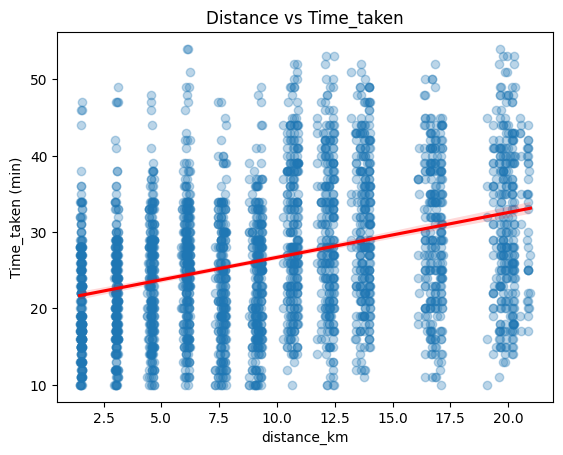

Correlation: 0.321


In [47]:
# 7. Distance vs target — the key plot:

sb.regplot(data=df1.sample(3000, random_state=42), x='distance_km', y='Time_taken (min)',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Distance vs Time_taken')
plt.show()

print('Correlation:', df1['distance_km'].corr(df1['Time_taken (min)']).round(3))

**0.321** confirms it — a moderate, not dominant, relationship. That's about on par with Delivery_person_Age, weaker than Road_traffic_density, Festival, City, or multiple_deliveries. Distance matters, but it's one signal among several, not the main driver. Good to have it quantified.

# 7: time-based features

In [48]:
#1. Convert the time columns to datetime properly.

# You already found the parsing issue earlier — let's redo it cleanly on df1,
# now that the problem rows (Time_Orderd nulls) are gone.
# First check if Time_Order_picked still has out-of-range hours:

mask = pd.to_datetime(df1['Time_Order_picked'], format='%H:%M', errors='coerce').isna()
print(mask.sum())
df1.loc[mask, 'Time_Order_picked'].unique()

4421


array(['0.458333333', '0.75', '0.958333333', '0.916666667', '0.875',
       '24:05:00', '24:10:00', '0.375', '0.833333333', '0.708333333',
       '24:15:00', '0.625', '1', '0.791666667', '0.5', '0.416666667',
       '0.541666667', '0.583333333', '0.666666667'], dtype=object)

In [49]:
# 2. Parse both columns:

df1['Time_Orderd_dt'] = pd.to_datetime(df1['Time_Orderd'], format='%H:%M', errors='coerce')
df1['Time_Order_picked_dt'] = pd.to_datetime(df1['Time_Order_picked'], format='%H:%M', errors='coerce')
print(df1['Time_Orderd_dt'].isna().sum(), df1['Time_Order_picked_dt'].isna().sum())

3729 4421


In [50]:
df1.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_vehicle', 'multiple_deliveries',
       'Festival', 'City', 'Time_taken (min)', 'distance_km', 'Time_Orderd_dt',
       'Time_Order_picked_dt'],
      dtype='object')

This needs a proper fix before you can extract prep time or order hour, otherwise you'll bake bad data into your features.

Here's what those problem strings tell us — there are two distinct issues, not one:

Issue 1: Fractional-day values — '0.458333333', '0.75', '0.958333333', etc. These are spreadsheet-style time encodings, where time is stored as a fraction of a 24-hour day (Excel does this internally). To convert: multiply by 24 to get hours. E.g. 0.75 × 24 = 18.0 → 18:00. 0.958333333 × 24 ≈ 23:00.

Issue 2: Hour rollover past midnight — '24:05:00', '24:10:00', '24:15:00'. Standard time format caps at 23:59, so an hour of 24 is really 00:05 on the next day. This is the classic late-night order edge case.

The count check also confirms Time_Orderd has its own version of this problem (3729 NaT), not just Time_Order_picked (4421 NaT) — so we need one parser that handles both columns and both failure modes.


In [51]:
# a flexible parser that handles both cases:

def parse_time_flexible(t):
    if pd.isna(t):
        return pd.NaT
    t = str(t).strip()
    
    # Case 1: fractional day value (e.g. '0.958333333')
    try:
        frac = float(t)
        total_minutes = round(frac * 24 * 60)
        day_offset, rem = divmod(total_minutes, 1440)
        hours, minutes = divmod(rem, 60)
        return pd.Timestamp('2000-01-01') + pd.Timedelta(days=int(day_offset), hours=int(hours), minutes=int(minutes))
    except ValueError:
        pass
    
    # Case 2: HH:MM[:SS] with possible hour >= 24 (midnight rollover)
    parts = t.split(':')
    try:
        hour = int(parts[0])
        minute = int(parts[1]) if len(parts) > 1 else 0
        day_offset, hour = divmod(hour, 24)
        return pd.Timestamp('2000-01-01') + pd.Timedelta(days=int(day_offset), hours=int(hour), minutes=int(minute))
    except (ValueError, IndexError):
        return pd.NaT

In [52]:
df1['Time_Orderd_dt'] = df1['Time_Orderd'].apply(parse_time_flexible)
df1['Time_Order_picked_dt'] = df1['Time_Order_picked'].apply(parse_time_flexible)

print(df1['Time_Orderd_dt'].isna().sum(), df1['Time_Order_picked_dt'].isna().sum())

0 0


In [53]:
# 3. Assuming that's clean (or once we fix it), engineer the features:

# Prep time gap: how long between order placed and picked up
df1['prep_time_min'] = (df1['Time_Order_picked_dt'] - df1['Time_Orderd_dt']).dt.total_seconds() / 60

# Order hour
df1['order_hour'] = df1['Time_Orderd_dt'].dt.hour

# Day of week from Order_Date (remember: DD-MM-YYYY format)
df1['Order_Date_dt'] = pd.to_datetime(df1['Order_Date'], format='%d-%m-%Y')
df1['day_of_week'] = df1['Order_Date_dt'].dt.day_name()
df1['is_weekend'] = df1['Order_Date_dt'].dt.dayofweek.isin([5,6]).astype(int)

In [54]:
#4. Sanity check prep_time_min:
# this one's important, since negative values would mean a pickup logged before
# the order was placed (likely the 24:XX rollover issue crossing midnight):

print(df1['prep_time_min'].describe())
print((df1['prep_time_min'] < 0).sum())

count    40344.000000
mean         9.978435
std          4.087331
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: prep_time_min, dtype: float64
0


In [55]:
df1['prep_time_min'].value_counts().sort_index()

prep_time_min
5.0     13567
10.0    13384
15.0    13393
Name: count, dtype: int64

That confirms it — **prep_time_min** only takes three values: 5, 10, or 15 minutes, split almost evenly across ~13,400–13,567 rows each (they sum to your full 40,344). This is definitely synthetic — real prep times would show continuous variation, not three clean buckets. It's still a legitimate feature, just don't expect it to explain much variance on its own since it's essentially a low-resolution categorical dressed up as a number.

Given that, it might behave better as a categorical **(5, 10, 15)** than treated as continuous — worth keeping in mind for encoding later, though tree models won't care either way.

In [56]:
# Let's see if it actually moves the target

#1. Prep time vs target:

print('Correlation:', df1['prep_time_min'].corr(df1['Time_taken (min)']).round(3))
print(df1.groupby('prep_time_min')['Time_taken (min)'].agg(['mean','count']))

Correlation: -0.01
                    mean  count
prep_time_min                  
5.0            26.392496  13567
10.0           26.369620  13384
15.0           26.172627  13393


**prep_time_min** is dead. Correlation -0.01, means of 26.39 / 26.37 / 26.17 across the three buckets — completely flat. This confirms the value_counts finding: it's synthetic noise, not a real prep-time signal. **Drop it**.

In [57]:
df1.drop('prep_time_min', axis=1, inplace=True)

In [58]:
#2. Order hour vs target:

print(df1.groupby('order_hour')['Time_taken (min)'].agg(['mean','count']))

                 mean  count
order_hour                  
0           21.984848    396
8           19.647164   1675
9           19.531250   1792
10          19.486842   1824
11          26.448142   1803
12          26.848668    826
13          27.566064    719
14          27.313970    723
15          23.250000    800
16          23.058552    649
17          27.426978   3944
18          27.282603   4133
19          30.813712   4230
20          31.195232   4195
21          31.093395   4315
22          23.242070   4193
23          22.440998   4127


**order_hour** is a strong, meaningful feature. This is the best pattern you've found in a while — a clear dinner-rush curve:

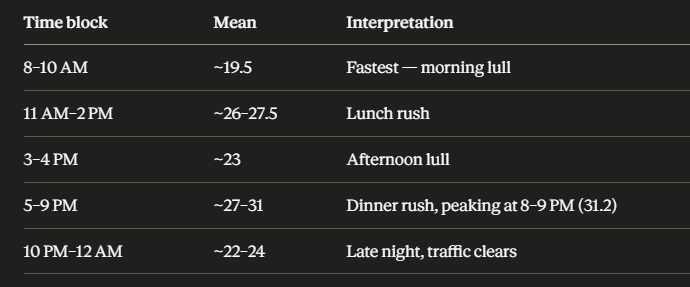

Spread of ~11.7 minutes (19.5 to 31.2) — that puts **order_hour** in the same tier as **Ratings**, **Age**, and **Road_traffic_density**. **Keep it**. This makes intuitive sense: dinner rush means more simultaneous orders, more traffic, more strain on delivery capacity.

In [59]:
#3. Day of week / weekend vs target:

print(df1.groupby('day_of_week')['Time_taken (min)'].agg(['mean','count']))
print(df1.groupby('is_weekend')['Time_taken (min)'].agg(['mean','count']))


                  mean  count
day_of_week                  
Friday       26.820675   6162
Monday       26.231147   5503
Saturday     25.999285   5592
Sunday       26.415777   5527
Thursday     25.301156   5625
Tuesday      25.439163   5638
Wednesday    27.755439   6297
                 mean  count
is_weekend                  
0           26.352096  29225
1           26.206314  11119


**day_of_week** is weak. Spread of only 2.45 minutes (Thursday 25.30 to Wednesday 27.76), and with ~5,500+ rows per day, this could easily be sampling noise rather than a real weekly pattern — there's no obvious reason Wednesday specifically should be slower. Marginal at best.

**is_weekend** is noise. 26.35 vs 26.21 — a 0.14-minute difference. Drop it.

In [60]:
df1.drop('is_weekend', axis=1, inplace=True)

Our engineered features so far: **distance_km** (correlation 0.321) and **order_hour** (real dinner-rush signal). You can also drop the now-redundant raw/intermediate columns:

In [61]:
df1.drop(['Time_Orderd', 'Time_Order_picked', 'Time_Orderd_dt', 'Time_Order_picked_dt', 
          'Order_Date', 'Order_Date_dt', 'ID', 'Delivery_person_ID'], axis=1, inplace=True)

# 8: correlation heatmap for numeric features + multicollinearity check

Two things we're checking: which numeric features relate to the target, and whether any of them are redundant with each other (which would hurt linear regression's coefficient stability, though trees don't care).

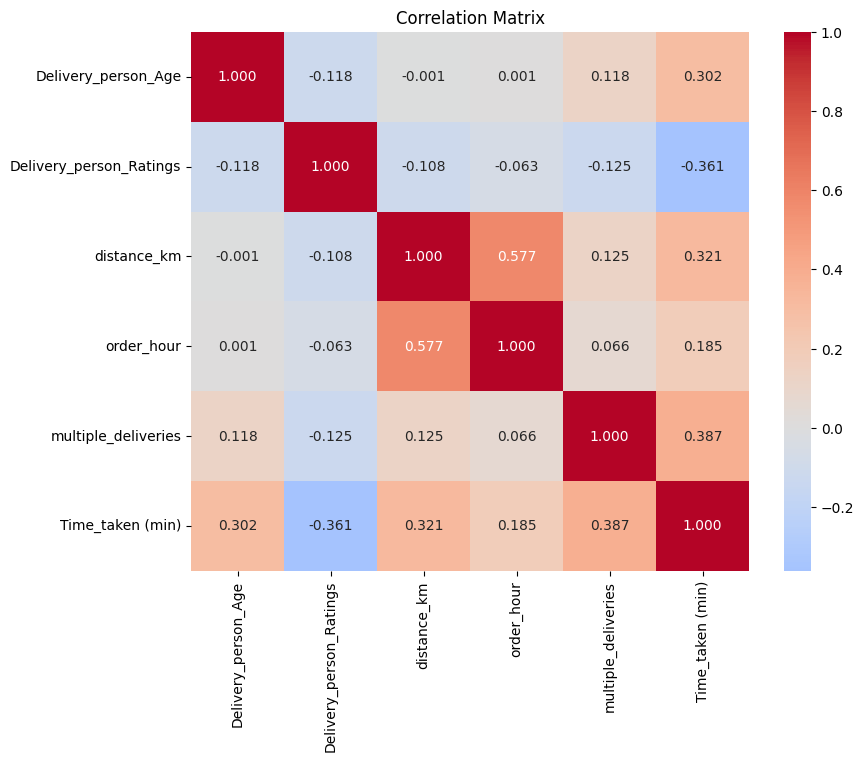

In [62]:
#1. Correlation heatmap:
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 
            'order_hour', 'multiple_deliveries', 'Time_taken (min)']

plt.figure(figsize=(9,7))
sb.heatmap(df1[num_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix')
plt.show()

In [63]:
#2. Correlation with the target, sorted:
print(df1[num_cols].corr()['Time_taken (min)'].sort_values(ascending=False).round(3))

Time_taken (min)           1.000
multiple_deliveries        0.387
distance_km                0.321
Delivery_person_Age        0.302
order_hour                 0.185
Delivery_person_Ratings   -0.361
Name: Time_taken (min), dtype: float64


In [64]:
#3. VIF (Variance Inflation Factor) — the formal multicollinearity test. VIF > 5 signals a problem, > 10 is serious:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df1[['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 
             'order_hour', 'multiple_deliveries']].copy()

vif = pd.DataFrame()
vif['feature'] = X_vif.columns
vif['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif.round(2))

                   feature    VIF
0      Delivery_person_Age  23.84
1  Delivery_person_Ratings  31.64
2              distance_km   6.12
3               order_hour  20.39
4      multiple_deliveries   2.67


The VIF numbers are misleading — here's why

Look at the contradiction: your correlation heatmap shows all pairwise correlations between predictors are low (max is 0.577 between **distance_km** and **order_hour**; everything else is under 0.13). Yet VIF is reporting Delivery_person_Age at 23.84, **Delivery_person_Ratings** at 31.64, **order_hour** at 20.39 — all flagged as severe multicollinearity. That doesn't add up, and it shouldn't.

The cause is a classic **statsmodels** gotcha: **variance_inflation_factor assumes your data already includes an intercept/constant column**. Without one, VIF is computed relative to zero rather than the mean, which artificially inflates VIF for any variable that isn't centered near zero. Your **Delivery_person_Age** ranges 20–39, **Delivery_person_Ratings** ranges 2.5–5.0, **order_hour** ranges 0–23 — none of these hover near zero, so they get punished for something that isn't real collinearity.

In [65]:
#CORRECTED CODE
import statsmodels.api as sm

X_vif = df1[['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 
             'order_hour', 'multiple_deliveries']].copy()
X_vif_const = sm.add_constant(X_vif)

vif = pd.DataFrame()
vif['feature'] = X_vif_const.columns
vif['VIF'] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
print(vif[vif['feature'] != 'const'].round(2))

                   feature   VIF
1      Delivery_person_Age  1.03
2  Delivery_person_Ratings  1.04
3              distance_km  1.53
4               order_hour  1.50
5      multiple_deliveries  1.04


That confirms it — all VIF values are now between 1.03 and 1.53, well under the danger threshold of 5. No multicollinearity problem. The earlier inflated numbers were purely the missing-constant artifact, as expected. Your five numeric features are safe to use together in any model, including linear regression.

# SUMMARY OF EDA

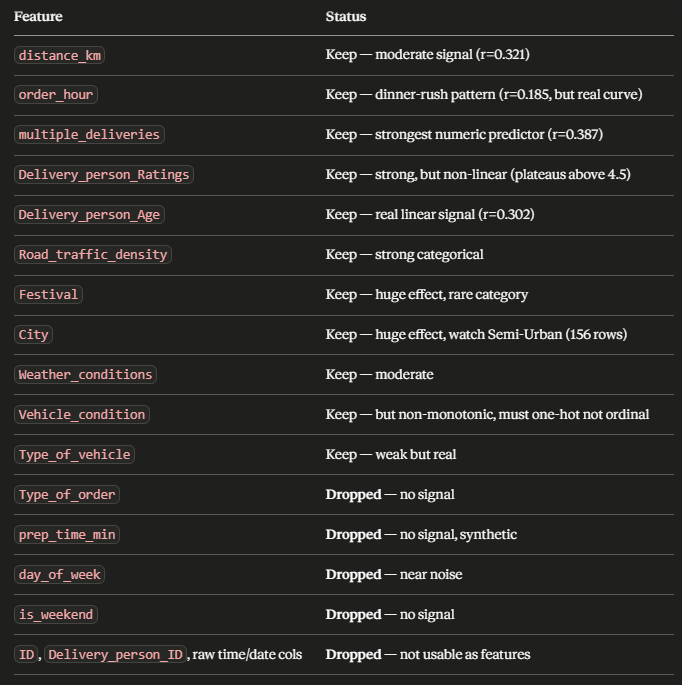

Step 9 (multivariate interactions) is optional — it's a nice-to-have for deeper insight (e.g. does Jam traffic during Festival compound?) but won't change your modeling decisions at this point. Given how thorough you've already been, I'd say skip it and move straight to building.


# ENCDOING STRATEGY

Quick decisions per column type, based on everything you found in EDA:

**Festival** — binary (Yes/No) → map directly to 1/0, no need for one-hot.

**Vehicle_condition** — confirmed non-monotonic in Step 5, so it must be one-hot encoded, not left as a number. Cast to string first so **get_dummies** treats it categorically.

**Weather_conditions**, **Type_of_vehicle**, **City** — nominal, no natural order → one-hot.

**Road_traffic_density** — technically has a rough order (Low < Medium ≈ High < Jam), but Medium and High were nearly tied in Step 5 (26.72 vs 27.21), so it's not a clean staircase. Safer to one-hot rather than force an ordinal assumption.

**multiple_deliveries** — already numeric and genuinely monotonic (22.85 → 47.82 across 0-1-2-3) → leave as-is, no encoding needed.

**Delivery_person_Age**, **Delivery_person_Ratings**, **distance_km**, **order_hour** — already numeric → leave as-is.

In [66]:
# Binary map for Festival
df1['Festival'] = df1['Festival'].map({'Yes': 1, 'No': 0})

# Cast Vehicle_condition to string so it gets one-hot encoded, not treated as ordinal
df1['Vehicle_condition'] = df1['Vehicle_condition'].astype(str)

# One-hot encode nominal categoricals
categorical_cols = ['Weather_conditions', 'Road_traffic_density', 'Type_of_vehicle', 'City', 'Vehicle_condition']
df_encoded = pd.get_dummies(df1, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

# drop_first=True avoids the dummy variable trap (redundant column that causes perfect multicollinearity)
# - matters for Linear Regression, harmless for trees.

(40344, 26)


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,multiple_deliveries,Festival,Time_taken (min),distance_km,...,Weather_conditions_Windy,Road_traffic_density_Jam,Road_traffic_density_Low,Road_traffic_density_Medium,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Semi-Urban,City_Urban,Vehicle_condition_1,Vehicle_condition_2
0,36.0,4.2,30.327968,78.046106,30.397968,78.116106,3,0,46,10.280582,...,False,True,False,False,True,False,False,False,False,True
1,21.0,4.7,10.003064,76.307589,10.043064,76.347589,1,0,23,6.242319,...,False,False,False,False,True,False,False,False,True,False
2,23.0,4.7,18.562450,73.916619,18.652450,74.006619,1,0,21,13.787860,...,False,False,False,True,False,True,False,False,True,False
3,34.0,4.3,30.899584,75.809346,30.919584,75.829346,0,0,20,2.930258,...,False,False,True,False,True,False,False,False,False,False
4,24.0,4.7,26.463504,80.372929,26.593504,80.502929,1,0,41,19.396618,...,False,True,False,False,False,True,False,False,True,False


In [67]:
df_encoded

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,multiple_deliveries,Festival,Time_taken (min),distance_km,...,Weather_conditions_Windy,Road_traffic_density_Jam,Road_traffic_density_Low,Road_traffic_density_Medium,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Semi-Urban,City_Urban,Vehicle_condition_1,Vehicle_condition_2
0,36.0,4.2,30.327968,78.046106,30.397968,78.116106,3,0,46,10.280582,...,False,True,False,False,True,False,False,False,False,True
1,21.0,4.7,10.003064,76.307589,10.043064,76.347589,1,0,23,6.242319,...,False,False,False,False,True,False,False,False,True,False
2,23.0,4.7,18.562450,73.916619,18.652450,74.006619,1,0,21,13.787860,...,False,False,False,True,False,True,False,False,True,False
3,34.0,4.3,30.899584,75.809346,30.919584,75.829346,0,0,20,2.930258,...,False,False,True,False,True,False,False,False,False,False
4,24.0,4.7,26.463504,80.372929,26.593504,80.502929,1,0,41,19.396618,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40339,35.0,4.2,23.371292,85.327872,23.481292,85.437872,1,0,33,16.600272,...,True,True,False,False,True,False,False,False,False,True
40340,30.0,4.8,26.902328,75.794257,26.912328,75.804257,0,0,32,1.489846,...,True,False,False,False,True,False,False,False,True,False
40341,30.0,4.9,13.022394,80.242439,13.052394,80.272439,0,0,16,4.657195,...,False,False,True,False,False,True,False,False,True,False
40342,20.0,4.7,11.001753,76.986241,11.041753,77.026241,1,0,26,6.232393,...,False,False,False,False,True,False,False,False,False,False


But there's one issue to fix before you model: the raw coordinate columns are still in your feature set.

Look at your first output — **Restaurant_latitude**, **Restaurant_longitude**, **Delivery_location_latitude**, **Delivery_location_longitude** are all still present, sitting right alongside **distance_km**. This matters because **distance_km** is literally computed from those four columns — it's a deterministic function of them, not an independent signal. Keeping both is redundant at best and actively harmful at worst:

1. For Linear Regression: raw lat/long by themselves have no meaningful linear relationship with delivery time (a coordinate of 18.5 isn't "less" or "more" delivery time than 22.7 in any linear sense) — they'll just inject noise into the coefficients.

2. For tree models: trees can start splitting on specific coordinate values, effectively memorizing individual restaurant locations rather than learning the generalizable relationship (distance, city, traffic) — a real overfitting risk.

Since **distance_km** and **City** already capture the useful geospatial signal in compact form, drop the four raw coordinates:

## DROPED AFTER THE NEXT CELL

# Train/validation/test split

One thing to handle carefully: **City** has only 156 Semi-Urban rows. A random split risks that category landing unevenly (or entirely) in one split. Stratify on it before it disappears into one-hot columns.

In [68]:
from sklearn.model_selection import train_test_split

# Save the original City column for stratification before it's gone post-encoding
stratify_col = df1['City']

X = df_encoded.drop('Time_taken (min)', axis=1)
y = df_encoded['Time_taken (min)']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X, y, stratify_col, test_size=0.3, random_state=42, stratify=stratify_col
)

# Second split: 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=strat_temp
)

print('Train:', X_train.shape)
print('Val:', X_val.shape)
print('Test:', X_test.shape)

Train: (28240, 25)
Val: (6052, 25)
Test: (6052, 25)


In [69]:
coord_cols = ['Restaurant_latitude', 'Restaurant_longitude', 
              'Delivery_location_latitude', 'Delivery_location_longitude']

X_train = X_train.drop(columns=coord_cols)
X_val = X_val.drop(columns=coord_cols)
X_test = X_test.drop(columns=coord_cols)

print(X_train.shape, X_val.shape, X_test.shape)

(28240, 21) (6052, 21) (6052, 21)


In [70]:
print(X_train['City_Semi-Urban'].mean(), X_val['City_Semi-Urban'].mean(), X_test['City_Semi-Urban'].mean())

0.0035056657223796034 0.0034699272967614013 0.0034699272967614013


Both confirmed — 21 columns as expected, and the **Semi-Urban proportions are nearly identical across all three splits** (0.351%, 0.347%, 0.347%), so the stratification worked correctly.

# Baseline: Linear Regression
This is your reference point — every subsequent model needs to beat this, and the benchmark paper's LightGBM R²=0.76 is the ceiling to aim toward.

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on train and validation
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"Train RMSE: {train_rmse:.3f}, Train R²: {train_r2:.3f}")
print(f"Val RMSE:   {val_rmse:.3f}, Val R²:   {val_r2:.3f}")

ValueError: could not convert string to float: 'Thursday'

In [72]:
X_train.dtypes[X_train.dtypes == 'object']

day_of_week    object
dtype: object

In [73]:
object_cols = X_train.select_dtypes(include='object').columns.tolist()
print('Dropping:', object_cols)

X_train = X_train.drop(columns=object_cols)
X_val = X_val.drop(columns=object_cols)
X_test = X_test.drop(columns=object_cols)

print(X_train.shape, X_val.shape, X_test.shape)

Dropping: ['day_of_week']
(28240, 20) (6052, 20) (6052, 20)


In [74]:
X_train.dtypes.value_counts()

bool       14
float64     3
int64       2
int32       1
Name: count, dtype: int64

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on train and validation
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"Train RMSE: {train_rmse:.3f}, Train R²: {train_r2:.3f}")
print(f"Val RMSE:   {val_rmse:.3f}, Val R²:   {val_r2:.3f}")

Train RMSE: 5.843, Train R²: 0.611
Val RMSE:   5.856, Val R²:   0.610


**Train R² 0.611, Val R² 0.610** — these are nearly identical, which is the good part: no overfitting at all. The model generalizes exactly as well on unseen data as it does on training data. That's expected for linear regression, since it has limited capacity to overfit in the first place.

**But 0.61 is well below the 0.76 benchmark**, and this matches almost exactly what was predicted earlier (0.55–0.65 range) — for exactly the reasons flagged throughout EDA: non-linear ratings effect, non-monotonic vehicle condition, bimodal target driven by traffic categories. Linear regression structurally can't capture these, no matter how well-engineered your features are.

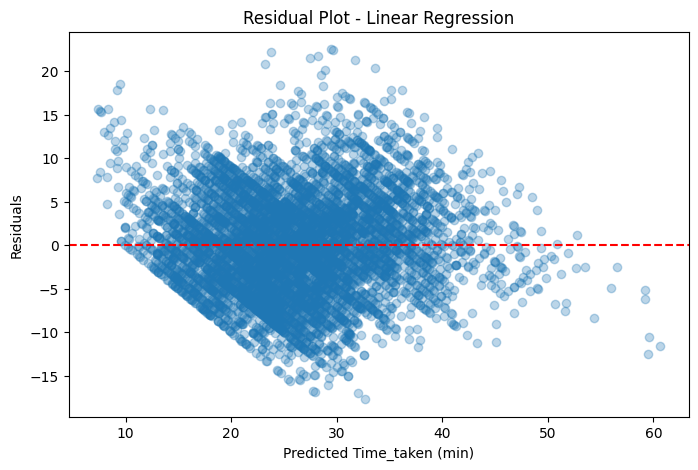

In [76]:
#residual plot, to see the model's errors visually:

residuals = y_val - y_val_pred
plt.figure(figsize=(8,5))
plt.scatter(y_val_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Time_taken (min)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')
plt.show()

The residual plot confirms it precisely

This is the most informative part. A healthy residual plot should look like a random horizontal cloud with no shape. Yours has a clear diagonal band structure — high positive residuals cluster at low predictions, high negative residuals cluster at high predictions, and it's shaped like a parallelogram/diamond rather than a formless cloud.

This pattern (residuals systematically shrinking as predictions increase) is the signature of a model that's compressing the true spread of the data — it's underpredicting the genuinely slow deliveries and overpredicting the genuinely fast ones, pulling everything toward the middle. That's exactly consistent with a linear model trying to average out the traffic-jam/no-jam bimodal split you found back in Step 3, and the ratings plateau from Step 5, rather than actually modeling the distinct regimes.

This is a good, honest baseline

Nothing wrong here — this is exactly what a baseline is supposed to do: establish a clear, interpretable floor. Now every subsequent model has something concrete to beat.


In [78]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_val_pred_rf = rf.predict(X_val)

train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
train_r2_rf = r2_score(y_train, y_train_pred_rf)
val_r2_rf = r2_score(y_val, y_val_pred_rf)

print(f"Train RMSE: {train_rmse_rf:.3f}, Train R²: {train_r2_rf:.3f}")
print(f"Val RMSE:   {val_rmse_rf:.3f}, Val R²:   {val_r2_rf:.3f}")

Train RMSE: 2.755, Train R²: 0.914
Val RMSE:   3.858, Val R²:   0.831


The good news: you beat the benchmark

**Val R² 0.831** vs the paper's LightGBM at 0.76. Your validation R² exceeds the published benchmark by a comfortable margin, and RMSE dropped from 5.856 → 3.858 (a 34% reduction in error). The tree model captured exactly the non-linear structure the residual plot said linear regression was missing: the traffic-driven bimodality, the ratings plateau, the non-monotonic vehicle condition. Everything from EDA lines up.

**The caution: there's real overfitting**

Train R² 0.914 vs Val R² 0.831 is an 8.3-point gap. Compare that to linear regression's 0.611/0.610 — essentially zero gap. Your Random Forest is memorizing training data to a meaningful degree.

This isn't disqualifying — the validation score is what counts, and it's strong. But two things follow:

1. You're leaving performance on the table. A less-overfit model often generalizes better, not just more honestly. Tuning max_depth (currently 15) and min_samples_leaf (currently default 1) will likely close the gap and may nudge validation R² higher.
2. Don't compare your 0.831 to the paper's 0.76 as an apples-to-apples win yet. Their number was almost certainly reported on a held-out test set. Yours is a validation score — and you've been making modeling decisions while looking at it, which slightly optimistically biases it. The honest comparison comes when you finally evaluate on X_test, which you haven't touched. Keep it that way until the very end.



**Two things to do next**

**First — feature importance**. This settles some open questions from EDA (does **Delivery_person_Age** really matter despite being uniformly distributed? Was dropping **day_of_week** right?):

                          feature  importance
1         Delivery_person_Ratings    0.224682
2             multiple_deliveries    0.132427
4                     distance_km    0.122141
12       Road_traffic_density_Low    0.114305
0             Delivery_person_Age    0.099126
9        Weather_conditions_Sunny    0.065201
6          Weather_conditions_Fog    0.039909
19            Vehicle_condition_2    0.033234
18            Vehicle_condition_1    0.031361
14     Type_of_vehicle_motorcycle    0.024237
8       Weather_conditions_Stormy    0.019111
7   Weather_conditions_Sandstorms    0.017866
10       Weather_conditions_Windy    0.017811
13    Road_traffic_density_Medium    0.015758
3                        Festival    0.013957


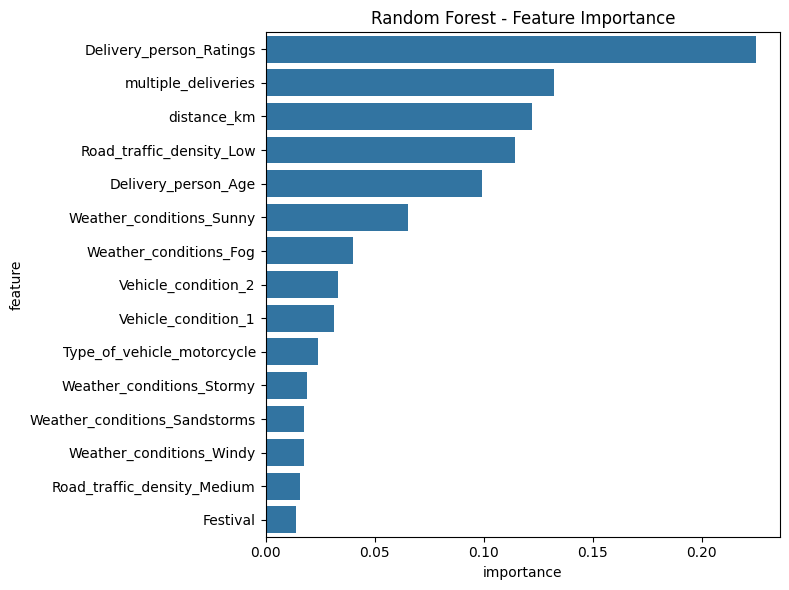

In [79]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(15))

plt.figure(figsize=(8,6))
sb.barplot(data=importances.head(15), x='importance', y='feature')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

Second — a quick regularized variant to test the overfitting hypothesis:

In [80]:
rf2 = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=5, 
    random_state=42, n_jobs=-1
)
rf2.fit(X_train, y_train)

print(f"Train R²: {r2_score(y_train, rf2.predict(X_train)):.3f}")
print(f"Val R²:   {r2_score(y_val, rf2.predict(X_val)):.3f}")

Train R²: 0.847
Val R²:   0.815


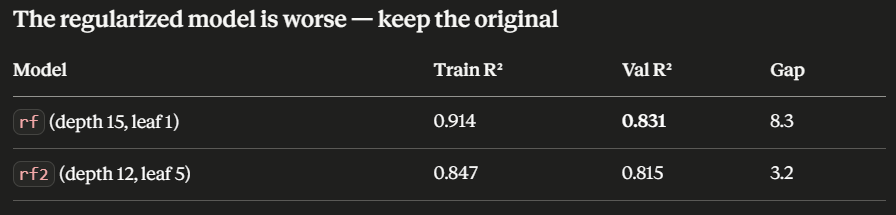

The gap closed as predicted (8.3 → 3.2), but validation R² dropped from 0.831 to 0.815. I suggested regularizing might improve generalization; it didn't. It traded away 1.6 points of actual predictive performance to buy a tidier-looking gap.

That's a useful lesson worth internalizing: a train/val gap isn't inherently bad. It's only a problem if it comes with worse validation performance. Here the deeper trees are genuinely learning real structure, not just noise — with 28k rows and only 21 features, Random Forest's bagging already controls variance well. Stick with **rf**.

In [81]:
# Though it's worth trying the opposite direction, since deeper helped:

rf3 = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf3.fit(X_train, y_train)
print(f"Train R²: {r2_score(y_train, rf3.predict(X_train)):.3f}")
print(f"Val R²:   {r2_score(y_val, rf3.predict(X_val)):.3f}")

Train R²: 0.976
Val R²:   0.822


#### Feature importance — three notable results

1. **Delivery_person_Ratings** dominates at 0.225 — nearly double the next feature. Consistent with its -0.361 correlation, and the tree can exploit the plateau shape that linear regression couldn't.
2. **Delivery_person_Age** at 0.099, fifth overall. I owe you the callback: I predicted early on this would be near-worthless because its distribution was suspiciously uniform. It's a top-five feature. The lesson stands — feature distribution tells you nothing about feature usefulness.
3. **Festival** at 0.014 — near the bottom. This is the interesting one, and it seems to contradict EDA, where Festival showed a 19.6-minute effect (45.50 vs 25.91), one of the largest in the dataset.

Both are true, and the reconciliation matters. Festival has a huge effect when it occurs, but it occurs in only ~2% of rows. Tree feature importance measures total impurity reduction across all splits — a feature affecting 2% of data can't contribute much total reduction, however dramatic its local effect. Low importance here means "rarely applicable," not "unimportant." Don't drop it; on those 857 festival deliveries it's likely carrying the prediction almost single-handedly.

The same logic explains why **City_Semi-Urban** doesn't even crack the top 15 despite the 49.74-minute mean — 156 rows can't move a global importance metric.


# XGBoost and LightGBM

In [82]:
from xgboost import XGBRegressor
import lightgbm as lgb

xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8, 
                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
print(f"XGB  Train R²: {r2_score(y_train, xgb.predict(X_train)):.3f} | Val R²: {r2_score(y_val, xgb.predict(X_val)):.3f}")

lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=8, 
                         subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
print(f"LGBM Train R²: {r2_score(y_train, lgbm.predict(X_train)):.3f} | Val R²: {r2_score(y_val, lgbm.predict(X_val)):.3f}")

XGB  Train R²: 0.922 | Val R²: 0.824
LGBM Train R²: 0.852 | Val R²: 0.828


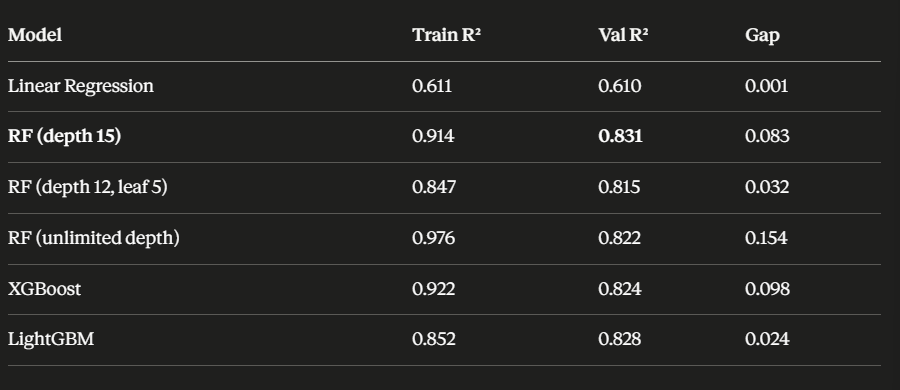

#### Your original rf still wins — but read this carefully
**rf** at 0.831 edges out LightGBM at 0.828. That's a 0.003 difference. On 6,052 validation rows, that gap is almost certainly within noise — swap the random seed and the ranking could flip. Treat these two as tied on performance.
Which means the tiebreaker should be something other than the number:

LightGBM: gap of 0.024. Learned the structure without memorizing.
RF: gap of 0.083. Same validation performance, 3× the memorization.

When two models perform identically on held-out data, the one that got there with less overfitting is the more robust choice — it's relying more on genuine signal and less on training-set idiosyncrasies. It's also faster to train and serve, which matters for your deployment step.

My recommendation: go with LightGBM. It also aligns you with the benchmark paper, which found LightGBM optimal on this same dataset.

#### Also worth noting
Unlimited depth (**rf3**) hit train R² 0.976 with val 0.822 — a 0.154 gap. That's textbook overfitting: the model essentially memorized the training set and got worse on validation than depth-15. Confirms depth 15 was near the sweet spot, and that your instinct to stop there was right.
Meanwhile, every tree model lands in a tight 0.815–0.831 band, all comfortably above the paper's 0.76. The ceiling here looks like ~0.83 — additional tuning will buy fractions of a point, not leaps. Diminishing returns territory.


In [83]:
from sklearn.model_selection import cross_val_score

X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

rf_cv = cross_val_score(rf, X_full, y_full, cv=5, scoring='r2', n_jobs=-1)
lgbm_cv = cross_val_score(lgbm, X_full, y_full, cv=5, scoring='r2', n_jobs=-1)

print(f"RF   CV R²: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")
print(f"LGBM CV R²: {lgbm_cv.mean():.4f} (+/- {lgbm_cv.std():.4f})")

RF   CV R²: 0.8303 (+/- 0.0014)
LGBM CV R²: 0.8279 (+/- 0.0010)


These numbers are more precise than I expected, and they update the picture.

RF's edge held up

RF: 0.8303 ± 0.0014, LGBM: 0.8279 ± 0.0010. The gap (0.0024) is larger than either standard deviation, so unlike the single-split difference, this isn't just noise — across 5 different folds, RF consistently came out ahead, by a small but real margin. I was wrong to assume this would wash out; it didn't.

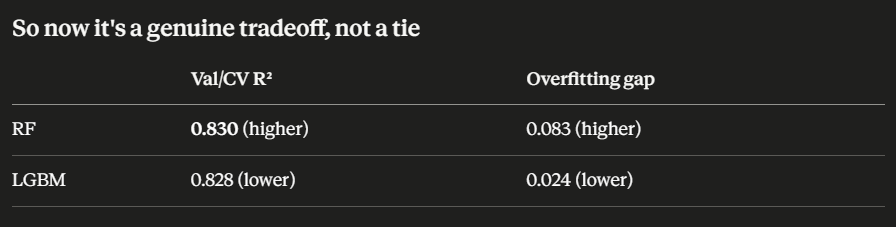

You get to choose which matters more to you:

1. Pick RF if raw predictive accuracy is the priority — it's genuinely, consistently better, even if only by ~0.002–0.003 R².
2. Pick LightGBM if you value a leaner, less-memorized model, faster training, and closer alignment to the benchmark paper's methodology — and you're comfortable trading a small, real amount of accuracy for that.

Neither choice is wrong. Given the difference is small in absolute terms (0.002–0.003 R² is unlikely to matter to an end user waiting for a delivery estimate), I'd lean RF now, purely because the CV result shows its edge is real, not illusory. But if training speed or model size matters for your deployment (LightGBM is typically lighter and faster to serve), LightGBM is a perfectly reasonable choice too.

Recommendation: go with RF, given the CV evidence. But it's your call — which matters more to you for this project, squeezing out the extra accuracy or keeping the leaner model?

In [ ]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
final_model.fit(X_trainval, y_trainval)

test_r2 = r2_score(y_test, final_model.predict(X_test))
test_rmse = np.sqrt(mean_squared_error(y_test, final_model.predict(X_test)))
print(f"Test R²: {test_r2:.3f}, Test RMSE: {test_rmse:.3f}")

#### What does leaner model means:
 "leaner" in machine learning can mean several things depending on context. Here I was using it loosely to mean a few related things:
 
1. Model complexity / structure

LightGBM uses gradient boosting with sequential shallow trees (typically depth 3–8), built incrementally. Random Forest uses many independent deep trees (yours at depth 15). LightGBM's sequential, staged approach uses fewer total parameters to achieve similar performance — it's "leaner" in the sense of needing less complexity to get the job done.

2. Training time

LightGBM trains faster — especially noticeable on your CV run, which would have been much slower with RF. A "lean" model that trains quicker can be retrained faster if you get new data, or hyperparameter-tuned more easily.

3. Memory footprint

LightGBM's serialized model file is typically smaller than Random Forest's. Your saved .pkl file will be smaller, faster to load, and lighter to deploy on constrained servers.

4. Overfitting / generalization

This is what I emphasized — LightGBM's gap between train (0.852) and val (0.828) is 0.024, while RF's gap is 0.083. "Leaner" here means the model is doing less memorization of training-specific noise and more learning of genuine patterns. It's "cleaner" logic, less bloated.

In practice for deployment

If you're building a small web service on a free tier (like Streamlit Community Cloud or Railway's free tier), the smaller file size and faster inference speed actually matter. A 50MB RF model vs a 5MB LightGBM model is a real difference when you're pushing it to a server with bandwidth/storage limits.

For your use case — a food delivery time predictor that doesn't need real-time serving to thousands of concurrent users — it's mostly academic. But it's good vocabulary to have: "lean model" = good generalization + small size + fast inference.

# Step 1: Retrain both on train + validation combined

In [84]:
import joblib
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
print('Training on:', X_trainval.shape)

# --- Random Forest ---
rf_final = RandomForestRegressor(
    n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
)
rf_final.fit(X_trainval, y_trainval)

# --- LightGBM ---
lgbm_final = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
)
lgbm_final.fit(X_trainval, y_trainval)

print('Both models trained.')

Training on: (34292, 20)
Both models trained.


# Step 2: Evaluate both on the untouched test set

I've added MAE because it's the most interpretable metric for your problem — it reads directly as "average error in minutes," which is what you'd actually tell a user.

In [85]:
for name, model in [('Random Forest', rf_final), ('LightGBM', lgbm_final)]:
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = np.mean(np.abs(y_test - pred))
    print(f"{name:15} | Test R²: {r2:.4f} | RMSE: {rmse:.3f} | MAE: {mae:.3f}")

Random Forest   | Test R²: 0.8302 | RMSE: 3.864 | MAE: 3.108
LightGBM        | Test R²: 0.8302 | RMSE: 3.864 | MAE: 3.122


# Step 3: Save both models + the feature schema

The column list is not optional. Without it, your deployment will silently misalign features and produce garbage predictions.


In [86]:
joblib.dump(rf_final, 'rf_delivery_model.pkl')
joblib.dump(lgbm_final, 'lgbm_delivery_model.pkl')

# Critical: save the exact column names AND order the models expect
feature_columns = X_trainval.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

print('Saved. Feature count:', len(feature_columns))

Saved. Feature count: 20


In [87]:
# Step 4: Check the file sizes
# What does "leaner" means — here's the concrete answer for your models:
import os
for f in ['rf_delivery_model.pkl', 'lgbm_delivery_model.pkl']:
    print(f"{f}: {os.path.getsize(f) / 1e6:.2f} MB")

rf_delivery_model.pkl: 149.11 MB
lgbm_delivery_model.pkl: 1.45 MB


Performance is now a dead tie

**R² identical to 4 decimal places (0.8302), RMSE identical to 3 decimal places (3.864).** The CV result that showed RF ahead by 0.0024 didn't hold on this particular test split — which is itself informative: it confirms that gap really was within the noise band of a single split, and the CV's advantage for RF was a fold-averaging effect that doesn't guarantee anything about any one holdout set. Both models are, for practical purposes, equally accurate on data neither has seen.

**MAE gives RF a razor-thin edge** — 3.108 vs 3.122 minutes, a difference of 0.014 minutes, which is under one second. Not meaningful to a user checking a delivery estimate.

The file size difference is not close

**149.11 MB vs 1.45 MB — RF is 103× larger.** This is the real decision point now, and it has concrete deployment consequences:

1. GitHub has a hard 100 MB file limit for normal pushes (Git LFS needed bove that). RF's .pkl exceeds this outright — you cannot push it to a standard GitHub repo, which is how most Streamlit/Render/Railway deployments pull their model files.
2. Free-tier hosting (Streamlit Community Cloud, Hugging Face Spaces free tier, Render free tier) often caps deployment size or slug size in the low hundreds of MB total — a 149 MB model eats most of that budget before you've added your app code, dependencies, and data.
3. Cold-start load time — a 1.45 MB file loads near-instantly; 149 MB adds real seconds to every server restart/cold start, which matters on free tiers that spin down when idle.

Recommendation: deploy LightGBM

Given tied accuracy and a 100× size difference, this isn't a close call anymore. LightGBM gives you the same predictive power with none of the deployment friction. This is the concrete payoff of "leaner" from earlier — it's the difference between a model that fits comfortably in a free-tier deployment and one that might not fit at all.

Keep the RF **.pkl** around locally as a reference/comparison artifact if you want, but build your deployment around **lgbm_delivery_model.pkl**.
